# IPL Match Winner Prediction

This notebook predicts whether the team batting first will win an IPL match.

I have kept this project simple and easy to explain because it is made as a student ML project for GitHub/CV.

Models used:

- Linear Regression baseline
- Logistic Regression
- Random Forest
- XGBoost, if installed

## 1. Import Libraries

Here I am importing the basic libraries for data cleaning, model training and evaluation.

In [1]:
from pathlib import Path
import warnings

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

## 2. Load Dataset

The code first checks if `data/IPL.csv` is available. If not, it downloads the dataset using KaggleHub.

In [2]:
DATA_DIR = Path("data")
MODEL_DIR = Path("models")
DATA_FILE = DATA_DIR / "IPL.csv"

if DATA_FILE.exists():
    print("Loading dataset from local data folder...")
    df = pd.read_csv(DATA_FILE, low_memory=False)
else:
    print("Local dataset not found, downloading from Kaggle...")
    import kagglehub

    dataset_path = Path(kagglehub.dataset_download("chaitu20/ipl-dataset2008-2025"))
    df = pd.read_csv(dataset_path / "IPL.csv", low_memory=False)

print("Dataset shape:", df.shape)
df.head()

Local dataset not found, downloading from Kaggle...


Dataset shape: (283678, 65)


,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_balls,team_wicket,new_batter,power_surge_start,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,141607,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,141608,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,141609,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,141610,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,3,0,NaN,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,141611,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,4,0,NaN,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


## 3. Make Match Level Data

The original dataset is ball-by-ball data. For winner prediction, I only need one row for each match, so I convert it into match-level data.

In [3]:
def clean_season(value):
    # Some seasons are written like 2007/08, so I convert them to a single year.
    value = str(value)
    season_map = {
        "2007/08": 2008,
        "2009/10": 2010,
        "2020/21": 2021,
    }

    if value in season_map:
        return season_map[value]

    return int(value[:4])


match_df = df.groupby("match_id").first().reset_index()

needed_cols = [
    "match_id", "date", "season", "venue", "city",
    "batting_team", "bowling_team", "toss_winner", "toss_decision",
    "match_won_by", "stage"
]

match_df = match_df[needed_cols].copy()
print("Match-level shape before cleaning:", match_df.shape)
match_df.head()

Match-level shape before cleaning: (1193, 11)


,match_id,date,season,venue,city,batting_team,bowling_team,toss_winner,toss_decision,match_won_by,stage
0,335982,2008-04-18,2007/08,M Chinnaswamy Stadium,Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Kolkata Knight Riders,Unknown
1,335983,2008-04-19,2007/08,"Punjab Cricket Association Stadium, Mohali",Chandigarh,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,Chennai Super Kings,Unknown
2,335984,2008-04-19,2007/08,Feroz Shah Kotla,Delhi,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,Delhi Daredevils,Unknown
3,335985,2008-04-20,2007/08,Wankhede Stadium,Mumbai,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,Unknown
4,335986,2008-04-20,2007/08,Eden Gardens,Kolkata,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,Kolkata Knight Riders,Unknown


## 4. Clean Team Names

I am using short team names because it makes the dataset and output easier to read.

In [4]:
team_map = {
    "Chennai Super Kings": "CSK",
    "Delhi Capitals": "DC",
    "Delhi Daredevils": "DC",
    "Gujarat Titans": "GT",
    "Kolkata Knight Riders": "KKR",
    "Mumbai Indians": "MI",
    "Punjab Kings": "PBKS",
    "Kings XI Punjab": "PBKS",
    "Rajasthan Royals": "RR",
    "Royal Challengers Bangalore": "RCB",
    "Royal Challengers Bengaluru": "RCB",
    "Sunrisers Hyderabad": "SRH",
    "Lucknow Super Giants": "LSG",
}

for col in ["batting_team", "bowling_team", "toss_winner", "match_won_by"]:
    match_df[col] = match_df[col].map(team_map)

current_teams = {"CSK", "DC", "GT", "KKR", "LSG", "MI", "PBKS", "RCB", "RR", "SRH"}

# I am removing old teams to keep the prediction problem simple.
match_df = match_df[
    match_df["batting_team"].isin(current_teams)
    & match_df["bowling_team"].isin(current_teams)
    & match_df["match_won_by"].isin(current_teams)
].copy()

match_df["season"] = match_df["season"].apply(clean_season)
match_df["date"] = pd.to_datetime(match_df["date"])
match_df = match_df.sort_values("date").reset_index(drop=True)

print("Match-level shape after cleaning:", match_df.shape)
print("Seasons:", match_df["season"].min(), "to", match_df["season"].max())

Match-level shape after cleaning: (986, 11)
Seasons: 2008 to 2026


## 5. Create Target and Basic Features

The target is `team1_won`.

- `team1` means the team batting first
- `team2` means the chasing team
- `team1_won = 1` means batting first team won
- `team1_won = 0` means chasing team won

In [5]:
match_df["team1"] = match_df["batting_team"]
match_df["team2"] = match_df["bowling_team"]
match_df["team1_won"] = (match_df["match_won_by"] == match_df["team1"]).astype(int)

match_df["toss_is_team1"] = (match_df["toss_winner"] == match_df["team1"]).astype(int)
match_df["toss_decision_bat"] = (match_df["toss_decision"] == "bat").astype(int)

knockout_stages = {"Final", "Qualifier 1", "Qualifier 2", "Eliminator", "Semi Final", "Elimination Final"}
match_df["is_knockout"] = match_df["stage"].isin(knockout_stages).astype(int)

match_df[["team1", "team2", "match_won_by", "team1_won", "toss_is_team1"]].head()

,team1,team2,match_won_by,team1_won,toss_is_team1
0,KKR,RCB,KKR,1,0
1,CSK,PBKS,CSK,1,1
2,RR,DC,DC,0,1
3,MI,RCB,RCB,0,1
4,PBKS,RR,RR,0,1


## 6. Historical Feature Engineering

Here I am creating simple features from past matches only.

This is important because if we use future match results, the model will get unfair information.

In [6]:
team_stats = {}
h2h_stats = {}
venue_stats = {}

team1_rates = []
team2_rates = []
h2h_rates = []
venue_team1_rates = []
venue_team2_rates = []

def get_team_rate(team):
    stats = team_stats.get(team, {"matches": 0, "wins": 0})
    if stats["matches"] == 0:
        return 0.5
    return stats["wins"] / stats["matches"]

def get_h2h_rate(team1, team2):
    key = tuple(sorted([team1, team2]))
    stats = h2h_stats.get(key)
    if not stats or stats["matches"] == 0:
        return 0.5
    return stats["wins"].get(team1, 0) / stats["matches"]

def get_venue_rate(team, venue):
    stats = venue_stats.get((team, venue), {"matches": 0, "wins": 0})
    if stats["matches"] == 0:
        return 0.5
    return stats["wins"] / stats["matches"]

for _, row in match_df.iterrows():
    team1 = row["team1"]
    team2 = row["team2"]
    venue = row["venue"]
    winner = team1 if row["team1_won"] == 1 else team2

    # First I save the past records before adding the current match result.
    team1_rates.append(get_team_rate(team1))
    team2_rates.append(get_team_rate(team2))
    h2h_rates.append(get_h2h_rate(team1, team2))
    venue_team1_rates.append(get_venue_rate(team1, venue))
    venue_team2_rates.append(get_venue_rate(team2, venue))

    # Now I update the records after the match is completed.
    for team in [team1, team2]:
        team_stats.setdefault(team, {"matches": 0, "wins": 0})
        team_stats[team]["matches"] += 1
        if team == winner:
            team_stats[team]["wins"] += 1

        venue_stats.setdefault((team, venue), {"matches": 0, "wins": 0})
        venue_stats[(team, venue)]["matches"] += 1
        if team == winner:
            venue_stats[(team, venue)]["wins"] += 1

    key = tuple(sorted([team1, team2]))
    h2h_stats.setdefault(key, {"matches": 0, "wins": {}})
    h2h_stats[key]["matches"] += 1
    h2h_stats[key]["wins"][winner] = h2h_stats[key]["wins"].get(winner, 0) + 1

match_df["team1_win_rate"] = team1_rates
match_df["team2_win_rate"] = team2_rates
match_df["h2h_team1_rate"] = h2h_rates
match_df["venue_team1_rate"] = venue_team1_rates
match_df["venue_team2_rate"] = venue_team2_rates

match_df["win_rate_diff"] = match_df["team1_win_rate"] - match_df["team2_win_rate"]
match_df["venue_rate_diff"] = match_df["venue_team1_rate"] - match_df["venue_team2_rate"]
match_df["h2h_diff"] = match_df["h2h_team1_rate"] - 0.5

match_df[["team1", "team2", "win_rate_diff", "h2h_diff", "venue_rate_diff"]].head()

,team1,team2,win_rate_diff,h2h_diff,venue_rate_diff
0,KKR,RCB,0.0,0.0,0.0
1,CSK,PBKS,0.0,0.0,0.0
2,RR,DC,0.0,0.0,0.0
3,MI,RCB,0.5,0.0,0.0
4,PBKS,RR,0.0,0.0,0.0


## 7. Quick Data Visualization

This gives a small idea about the target distribution.

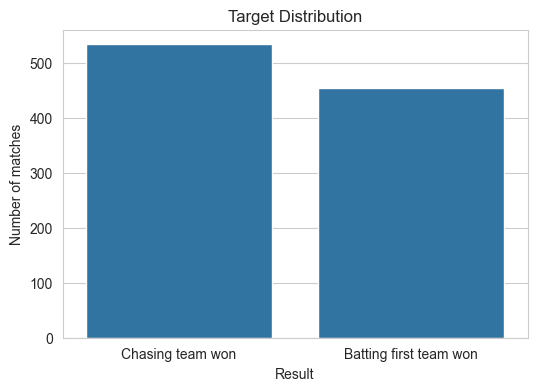

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=match_df, x="team1_won")
plt.xticks([0, 1], ["Chasing team won", "Batting first team won"])
plt.title("Target Distribution")
plt.xlabel("Result")
plt.ylabel("Number of matches")
plt.show()

## 8. Train-Test Split

I am using older seasons for training and recent seasons for testing. This is better than random split for sports data because matches happen over time.

In [8]:
numeric_features = [
    "season", "toss_is_team1", "toss_decision_bat", "is_knockout",
    "win_rate_diff", "venue_rate_diff", "h2h_diff"
]

categorical_features = ["team1", "team2", "venue", "city"]
features = numeric_features + categorical_features
target = "team1_won"

train = match_df[match_df["season"] <= 2022].copy()
test = match_df[match_df["season"] >= 2023].copy()

if len(train) == 0 or len(test) == 0:
    split_index = int(len(match_df) * 0.8)
    train = match_df.iloc[:split_index].copy()
    test = match_df.iloc[split_index:].copy()

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

print("Train matches:", len(train))
print("Test matches:", len(test))
print("Train seasons:", train["season"].min(), "to", train["season"].max())
print("Test seasons:", test["season"].min(), "to", test["season"].max())

Train matches: 749
Test matches: 237
Train seasons: 2008 to 2022
Test seasons: 2023 to 2026


## 9. Model Training

I am using preprocessing inside a pipeline, so numeric columns are scaled and categorical columns are one-hot encoded automatically.

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

models = {
    "Linear Regression Baseline": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=150,
            max_depth=6,
            min_samples_leaf=5,
            random_state=42
        ))
    ]),
}

try:
    from xgboost import XGBClassifier

    models["XGBoost"] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=120,
            max_depth=3,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=42
        ))
    ])
except Exception as error:
    print(f"XGBoost is not available on this system, so it will be skipped. Reason: {error}")

XGBoost is not available on this system, so it will be skipped. Reason: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/prakashraj/Documents/New project/ipl-match-winner-prediction/.venv/lib/python3.9/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <89AD948E-E564-3266-867D-7AF89D6488F0> /Users/prakashraj/Documents/New project/ipl-match-winner-prediction/.venv/lib/python3.9/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such f

## 10. Evaluate Models

I am comparing the models using accuracy and ROC-AUC.

In [10]:
def predict_for_metrics(model, X_test, model_name):
    if model_name == "Linear Regression Baseline":
        raw_score = model.predict(X_test)
        probability = np.clip(raw_score, 0, 1)
        prediction = (probability >= 0.5).astype(int)
        return prediction, probability

    prediction = model.predict(X_test)
    probability = model.predict_proba(X_test)[:, 1]
    return prediction, probability

results = []
fitted_models = {}

for name, model in models.items():
    print("Training", name)
    model.fit(X_train, y_train)

    y_pred, y_prob = predict_for_metrics(model, X_test, name)

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "ROC_AUC": round(roc_auc_score(y_test, y_prob), 3),
    })

    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
results_df

Training Linear Regression Baseline
Training Logistic Regression
Training Random Forest


,Model,Accuracy,ROC_AUC
1,Logistic Regression,0.511,0.495
0,Linear Regression Baseline,0.489,0.490
2,Random Forest,0.485,0.502


## 11. Best Model Report

Best Model: Logistic Regression
              precision    recall  f1-score   support

   Team2 won       0.51      0.58      0.55       120
   Team1 won       0.50      0.44      0.47       117

    accuracy                           0.51       237
   macro avg       0.51      0.51      0.51       237
weighted avg       0.51      0.51      0.51       237



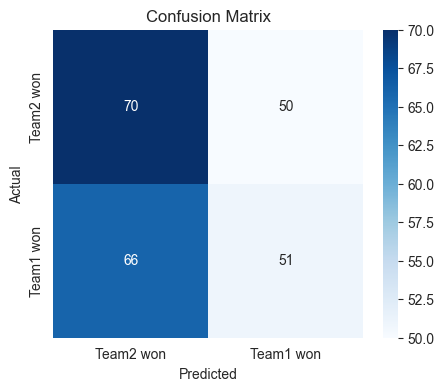

In [11]:
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

print("Best Model:", best_model_name)

best_pred, _ = predict_for_metrics(best_model, X_test, best_model_name)
print(classification_report(y_test, best_pred, target_names=["Team2 won", "Team1 won"]))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Team2 won", "Team1 won"], yticklabels=["Team2 won", "Team1 won"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 12. Save the Best Model

In [12]:
MODEL_DIR.mkdir(exist_ok=True)
with open(MODEL_DIR / "best_ipl_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("Best model saved at:", MODEL_DIR / "best_ipl_model.pkl")

Best model saved at: models/best_ipl_model.pkl
